# 12_时间序列分析方法-移动平均

## Notebook 使用说明

建议先阅读理论，再从上到下运行全部单元；使用 Python 3.11–3.13 内核。数据与辅助模块均来自本文件夹，安装依赖后无需联网获取案例数据。

本篇数据：`dataset/TSLA.csv`。

转写调整：

- 修复或适配代码；原讲解性输出保留为 Markdown，Python 单元按顺序执行。

原文参考图及静态数值仅用于对照；重跑后的代码输出为本次实验结果。依赖版本与验证记录见根目录 `README.md` 和 `reports/`。

In [1]:
# 从当前目录向上寻找本套 Notebook 的根目录，移动整个文件夹后仍可运行。
from pathlib import Path
import os, sys, tempfile, random
ROOT = next((p for p in [Path.cwd(), *Path.cwd().parents]
             if (p / "notebook_support.py").is_file()), None)
if ROOT is None:
    raise FileNotFoundError("请从这套 Notebook 文件夹内启动 Jupyter，并保留 notebook_support.py。")
sys.path.insert(0, str(ROOT))
os.environ.setdefault("MPLCONFIGDIR", str(Path(tempfile.gettempdir()) / "ml_notebooks_matplotlib"))
from notebook_support import DATA_DIR, load_local_housing, load_local_boston, load_local_mnist, load_creditcard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import font_manager
random.seed(42)
np.random.seed(42)
# 按实际安装的字体选择，兼容 macOS / Windows / Linux。
_available_fonts = {f.name for f in font_manager.fontManager.ttflist}
CJK_FONTS = [f for f in ["Arial Unicode MS", "PingFang SC", "Heiti TC", "Microsoft YaHei", "SimHei", "Noto Sans CJK SC"]
             if f in _available_fonts] + ["DejaVu Sans"]
plt.rcParams.update({"font.sans-serif": CJK_FONTS, "axes.unicode_minus": False,
                     "figure.dpi": 90, "figure.max_open_warning": 30})
%matplotlib inline


本文和大家详细的聊聊时间序列中的**移动平均**\~

之前总结了十大时间序列法的内容，大家有空可以看看，这里跳转。

**移动平均 是什么？**

首先说，**时间序列分析中的移动平均法**是一种用来平滑数据非常常用方法，尤其是当数据存在波动时，移动平均可以帮助我们消除短期的波动，揭示长期趋势。

**移动平均法的核心思路**是通过取一段时间内的数据平均值来代替这段时间的数据值。具体来说，对于时间序列数据中的每个时点，我们取这个时点前后一定数量的相邻数据点，计算这些点的平均值，然后用这个平均值替换原始数据中的当前时点的值。

根据时间窗口的不同，移动平均法可以分为：

1. **简单移动平均**（Simple Moving Average，SMA）：每个数据点的平均值都是由前面固定数量的时点数据计算得到，所有数据点的权重是相同的。
2. **加权移动平均**（Weighted Moving Average，WMA）：前面的时点赋予更高的权重，后面的时点赋予更低的权重。
3. **指数移动平均**（Exponential Moving Average，EMA）：越靠近当前时点的历史数据赋予的权重越大，而更早的数据权重更小。

**为了简单起见，我们这里主要讨论简单移动平均。**

#### 案例：小卖部的饮料销售分析

假设一个小卖部老板想要分析每天售出的饮料数量，并发现趋势。他记录了过去10天的销售情况如下：

- 第1天：10瓶
- 第2天：12瓶
- 第3天：11瓶
- 第4天：15瓶
- 第5天：14瓶
- 第6天：10瓶
- 第7天：13瓶
- 第8天：16瓶
- 第9天：15瓶
- 第10天：17瓶

我们用**3天的简单移动平均法**来平滑数据，分析这个小卖部饮料销售的趋势。

#### 如何计算移动平均？

**步骤：**

1. 取固定的时间窗口（这里是3天）。
2. 从第3天开始，每一天的移动平均值是该天及其前两天的数据的平均值。

例如：

- **第3天的移动平均值** = (第1天数据 + 第2天数据 + 第3天数据) / 3 = (10 + 12 + 11) / 3 = 11
- **第4天的移动平均值** = (第2天数据 + 第3天数据 + 第4天数据) / 3 = (12 + 11 + 15) / 3 = 12.67
- **第5天的移动平均值** = (第3天数据 + 第4天数据 + 第5天数据) / 3 = (11 + 15 + 14) / 3 = 13.33

依此类推，继续计算后面的移动平均值。

#### 完整的计算结果

| 日期 | 销售量（瓶） | 3天移动平均值（瓶） |
|-|-|-|
| 第1天 | 10 | - |
| 第2天 | 12 | - |
| 第3天 | 11 | 11 |
| 第4天 | 15 | 12.67 |
| 第5天 | 14 | 13.33 |
| 第6天 | 10 | 13 |
| 第7天 | 13 | 12.33 |
| 第8天 | 16 | 13 |
| 第9天 | 15 | 14.67 |
| 第10天 | 17 | 16 |

从第3天开始，我们得到了一系列平滑后的移动平均值。这些值比原始数据波动更小，可以让我们更清楚地看到销售量的变化趋势。通过移动平均的结果可以看出，小卖部的饮料销量在第3天到第10天间逐渐上升。

移动平均法的本质是将原始数据中的短期波动去除，帮助我们更好地观察长期趋势。它就像用多次数据的“平均”来消除不必要的噪音，让我们专注于总体变化方向。

例如，如果你今天、明天、后天的饮料销量分别是10瓶、12瓶和11瓶，直接看这三个数字可能会觉得变化不大或者波动较大。但如果计算它们的平均值得到一个11瓶的数字，反映的是这几天的平均趋势，而不是单日波动。

移动平均法在很多领域都可以应用：

- **销售数据**：帮助分析销售趋势，去除季节性波动。
- **股市分析**：用于判断股票的价格趋势。
- **气候数据**：平滑气温或降雨量的变化，帮助气象分析。

希望这个案例和解释对你理解移动平均法有帮助！

## 公式解析

在时间序列分析中，**移动平均法**是一种经典的方法。

下面，我们从数学推导和公式推理的角度来详细解释移动平均方法，尤其是简单移动平均（SMA）的计算。

#### 简单移动平均（SMA）的定义

**简单移动平均**是对固定时间窗口内的数据点取算术平均值，逐步移动窗口来平滑时间序列。

假设我们有一个时间序列数据 $x_1, x_2, \dots, x_n$，则**简单移动平均**的公式为：


$$
SMA_t = \frac{1}{N} \sum_{i=t-N+1}^{t} x_i
$$


其中：

- $t$是当前时刻，$N$是移动平均窗口的大小。
- $x_i$是时间序列在第 $i$时刻的观测值。
- $SMA_t$是在时刻 $t$的移动平均值。

#### 算法推导

我们以 **N=3** 的简单移动平均为例，来推导其计算过程。

**1. 移动平均的本质**：是将时间序列中的每个时刻的值替换为该时刻及其前面 $N-1$个时刻的平均值。

**2. 公式解读**：

- $t$是当前的时间点，比如第 $t$天的饮料销售量；
- $N$是窗口大小，表示我们在每个时刻要用多少个数据点来计算平均值。

对于窗口大小为 3 的情况，简单移动平均值的计算公式为：


$$
SMA_t = \frac{x_t + x_{t-1} + x_{t-2}}{3}
$$


这个公式表示，时刻 $t$的简单移动平均值是 $t$、$t-1$、$t-2$三个时刻的值之和除以 3。

**3. 逐步计算：**

假设我们有一组时间序列数据：$x_1, x_2, x_3, \dots, x_6$，分别为：10, 12, 11, 15, 14, 10。我们使用窗口大小 $N = 3$来计算简单移动平均。

- 第 3 天的移动平均值：


$$
SMA_3 = \frac{x_3 + x_2 + x_1}{3} = \frac{11 + 12 + 10}{3} = 11
$$


- 第 4 天的移动平均值：


$$
SMA_4 = \frac{x_4 + x_3 + x_2}{3} = \frac{15 + 11 + 12}{3} = 12.67
$$


- 第 5 天的移动平均值：


$$
SMA_5 = \frac{x_5 + x_4 + x_3}{3} = \frac{14 + 15 + 11}{3} = 13.33
$$


- 第 6 天的移动平均值：


$$
SMA_6 = \frac{x_6 + x_5 + x_4}{3} = \frac{10 + 14 + 15}{3} = 13
$$


如此类推，每天的移动平均值就通过这个方式计算出来。

### 公式推理

我们从数学角度进一步推导这个公式。

#### 1. 从时间序列的性质推导：

对于一个时间序列 $\{x_1, x_2, \dots, x_t\}$，在每一个时刻 $t$，我们希望消除短期波动，得到更加平滑的序列。简单移动平均的想法就是对每个时刻的观测值 $x_t$，通过它与前 $N-1$个时刻的数据进行均值计算，表示这段时间的中心趋势。

因此，在时刻 $t$，我们对窗口内 $N$个数据点的加权方式是等权重的，即所有数据点的权重为 $\frac{1}{N}$，因此移动平均值可以表示为：


$$
SMA_t = \frac{x_t + x_{t-1} + \dots + x_{t-N+1}}{N}
$$


#### 2. 移动平均的平滑效果：

在时间序列数据中，常常包含高频波动（短期波动）和低频波动（长期趋势）。简单移动平均的作用是通过平滑高频波动，揭示低频波动的趋势。

简单移动平均法的平滑效果可以通过以下方式理解：

- 对于短期的波动（即高频部分），窗口内的数据相互抵消，从而削弱其影响。
- 对于长期趋势（低频部分），则因为窗口内的数据逐步移动，所以能够很好地保留长期趋势。

#### 3. 从加权的角度推理：

对于简单移动平均，每一个时间点 $x_t$的权重都是 $\frac{1}{N}$。如果我们将权重的思想扩展，得到加权移动平均（WMA）和指数移动平均（EMA）的概念。

例如，在加权移动平均中，不同的时间点可以赋予不同的权重，而在指数移动平均中，距离当前时间点较近的数据点权重更大，距离较远的权重更小。

## 完整案例

这里，咱们使用tesla的股票数据，进行一个**股票市场分析案例**的说明。案例中，分别展示原始数据、移动平均曲线，以及一些额外的分析图形，如不同时间窗口的移动平均比较，结合阴影区域展示趋势。

**导入所需库和数据**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# 使用matplotlib的样式库来增加图表炫酷效果
plt.style.use('seaborn-v0_8-darkgrid')

# 假设你从Kaggle导入了一个股票市场的数据，例如"Tesla"的历史价格数据
# 数据集可以包含日期、开盘价、收盘价、最高价、最低价等
# 在这里我们使用pandas的read_csv方法从本地读取数据
data = pd.read_csv(DATA_DIR / 'TSLA.csv')

# 查看数据的前几行，确保数据加载正确
print(data.head())

# 将日期转换为datetime格式，方便绘图
data['Date'] = pd.to_datetime(data['Date'])

# 只使用日期和收盘价两列
data = data[['Date', 'Close']]

# 将日期列设置为索引，便于时间序列分析
data.set_index('Date', inplace=True)

# 查看数据概况
print(data.describe())

         Date   Open   High    Low  Close  Adj Close    Volume
0  2010-06-29  3.800  5.000  3.508  4.778      4.778  93831500
1  2010-06-30  5.158  6.084  4.660  4.766      4.766  85935500
2  2010-07-01  5.000  5.184  4.054  4.392      4.392  41094000
3  2010-07-02  4.600  4.620  3.742  3.840      3.840  25699000
4  2010-07-06  4.000  4.000  3.166  3.222      3.222  34334500
             Close
count  2956.000000
mean    138.762183
std     250.123115
min       3.160000
25%      19.615000
50%      46.545000
75%      68.103998
max    1229.910034


**计算不同窗口的移动平均**

In [3]:
# 计算短期（10天）、中期（30天）和长期（60天）的移动平均
data['SMA_10'] = data['Close'].rolling(window=10).mean()
data['SMA_30'] = data['Close'].rolling(window=30).mean()
data['SMA_60'] = data['Close'].rolling(window=60).mean()

**绘制原始数据和移动平均曲线**

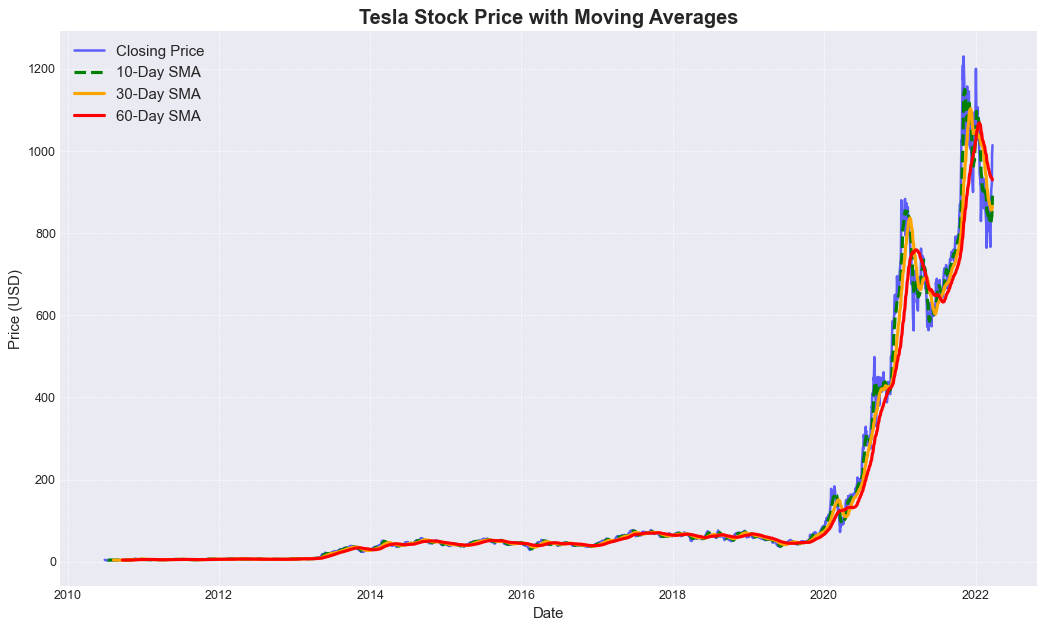

In [4]:
# 设置画布大小
plt.figure(figsize=(14, 8))

# 绘制原始数据（收盘价）曲线
plt.plot(data.index, data['Close'], label='Closing Price', color='blue', alpha=0.6, linewidth=2)

# 绘制10天、30天和60天的移动平均曲线
plt.plot(data.index, data['SMA_10'], label='10-Day SMA', color='green', linestyle='--', linewidth=2.5)
plt.plot(data.index, data['SMA_30'], label='30-Day SMA', color='orange', linestyle='-', linewidth=2.5)
plt.plot(data.index, data['SMA_60'], label='60-Day SMA', color='red', linestyle='-', linewidth=2.5)

# 设置标题和标签
plt.title('Tesla Stock Price with Moving Averages', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# 图例显示
plt.legend(loc='best', fontsize=12)

# 渐变效果
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# 显示图表
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_010.png)

**绘制增加阴影区域的复杂分析图形**

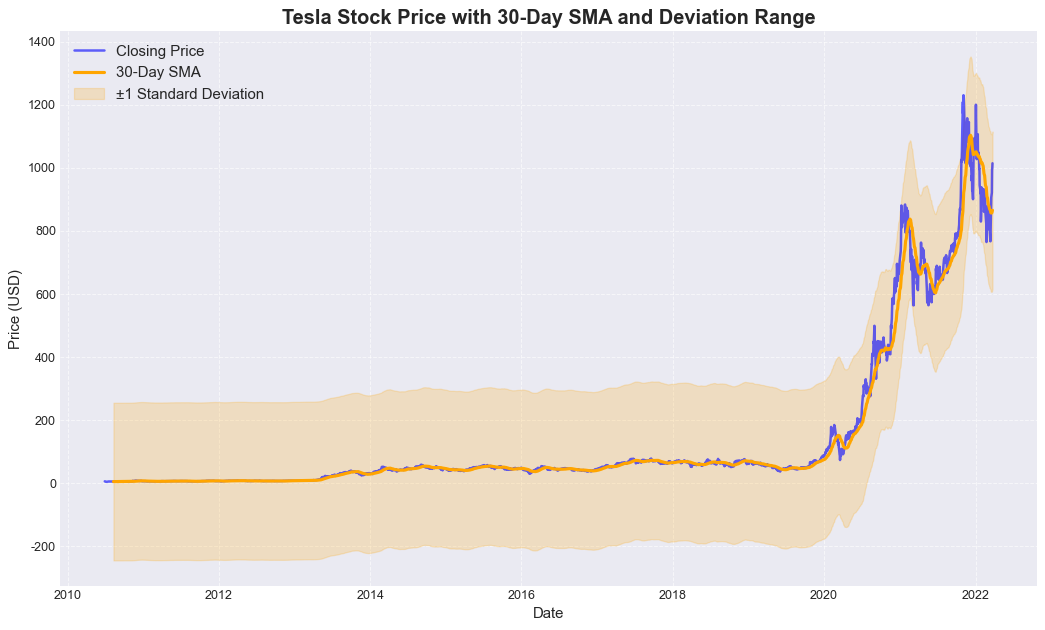

In [5]:
# 设置画布大小
plt.figure(figsize=(14, 8))

# 绘制收盘价曲线
plt.plot(data.index, data['Close'], label='Closing Price', color='blue', alpha=0.6, linewidth=2)

# 绘制30天移动平均线
plt.plot(data.index, data['SMA_30'], label='30-Day SMA', color='orange', linestyle='-', linewidth=2.5)

# 阴影区域，表示收盘价上下波动区间
plt.fill_between(data.index, data['SMA_30'] - data['Close'].std(), data['SMA_30'] + data['Close'].std(), 
                 color='orange', alpha=0.2, label='±1 Standard Deviation')

# 设置标题和标签
plt.title('Tesla Stock Price with 30-Day SMA and Deviation Range', fontsize=16, weight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Price (USD)', fontsize=12)

# 增加图例
plt.legend(loc='best', fontsize=12)

# 增加网格
plt.grid(True, linestyle='--', alpha=0.6)

# 展示图表
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_011.png)

**使用Seaborn增加复杂的热度图效果**

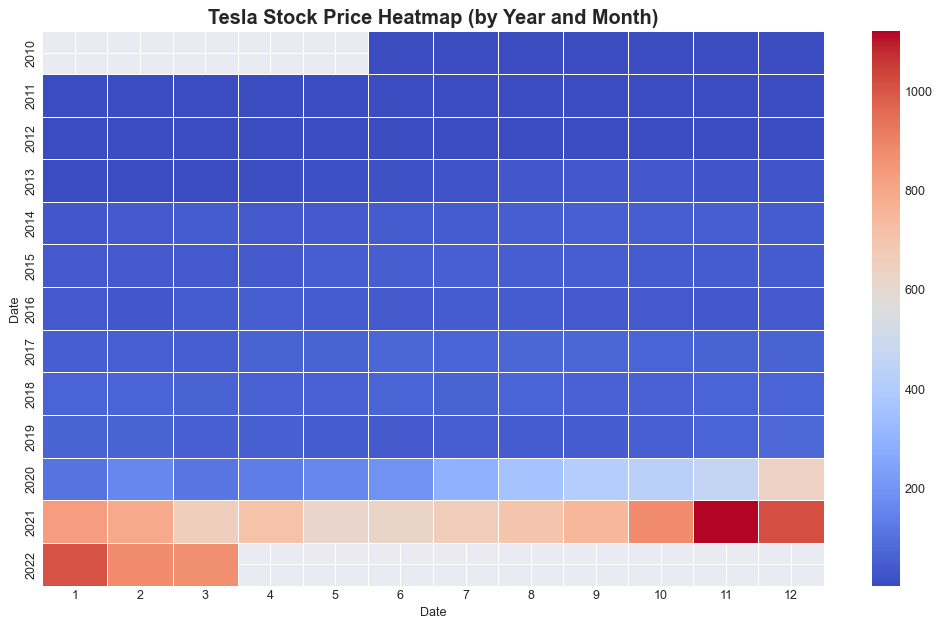

In [6]:
# 使用Seaborn绘制热度图分析价格变化趋势
plt.figure(figsize=(14, 8))

# 使用 Seaborn 的 color palette 来增加炫酷的色彩效果
colors = sns.color_palette("coolwarm", as_cmap=True)

# 绘制热度图，展示收盘价随时间的变化
sns.heatmap(data.pivot_table(values='Close', index=data.index.year, columns=data.index.month), cmap=colors, linewidths=0.5)

# 设置标题
plt.title('Tesla Stock Price Heatmap (by Year and Month)', fontsize=16, weight='bold')

# 展示图表
plt.show()

![原文参考图，当前结果见代码输出](attachments/img_012.png)

通过以上的Python代码，我们可以使用「移动平均」进行时间序列分析，并结合不同的图形展示数据：

- 第一个图展示了收盘价和不同时间窗口的移动平均线，帮助我们观察长期趋势。
- 第二个图结合阴影区域展示了30天移动平均的波动范围，增加了视觉复杂度。
- 最后一个使用Seaborn的热度图展示不同年份和月份的股票价格变化，使得分析更加直观。

## 模型分析

### 移动平均的作用与局限性

**作用**：

- 消除短期波动：通过取均值的方法，可以减少序列中的短期波动，突显长期趋势。
- 易于计算：简单移动平均公式简单，计算方便，应用广泛。

**局限性**：

- 滞后性：移动平均法会让序列中的趋势滞后，尤其是在趋势发生变化时，移动平均不能快速反映最新的趋势。
- 权重分布：对于简单移动平均，窗口内的数据点的权重是均匀的，但在实际情况中，较新的数据可能比较旧的数据更重要。

简单移动平均法的核心思想是对固定时间窗口内的数据点取均值，平滑数据，揭示趋势。

### 优缺点和适用场景

**优点：**

1. **简单易懂、容易实现**：移动平均法的计算非常直观和简单，只需取一段时间内的数据的算术平均值。对于初学者来说，这种方法易于理解和实现。
2. **平滑短期波动，突显长期趋势**：移动平均通过平滑掉数据中的短期波动，使得时间序列中的长期趋势更加明显，能够有效减少噪音的干扰。
3. **适合不需要复杂模型的应用**：对于一些无需复杂预测或分析的场景，移动平均是很好的选择，能够在简单的框架下提供有用的信息。

**缺点：**

1. **滞后性**：移动平均会引入滞后效应。由于每次计算是基于过去的数据，移动平均不能及时反映最新的数据变化，尤其是当趋势发生明显变化时，反应较慢。
2. **对周期性变化不敏感**：如果时间序列存在显著的周期性波动，简单移动平均很难有效捕捉这些周期性变化，可能会导致对趋势的误判。
3. **权重分布均匀**：简单移动平均法给窗口内的每个数据点相同的权重，没有考虑较近数据点可能比较远数据点更重要。因此，它在捕捉趋势的变化时效率不高。
4. **无法应对复杂的时间序列数据**：移动平均仅能处理比较简单的趋势分析，对于带有更复杂模式或噪声的数据集（例如非线性变化、大量噪声干扰等），效果不理想。

### 移动平均法的适用场景

**金融市场分析**：

- **股票价格走势**：移动平均法广泛应用于股票市场中，用于分析股票的价格趋势。常见的有**短期移动平均线（如5日线、10日线）和长期移动平均线（如50日线、200日线）**，帮助投资者识别市场的上升或下降趋势。
- **技术指标分析**：许多技术指标基于移动平均法，如“黄金交叉”（短期均线向上突破长期均线）和“死亡交叉”（短期均线向下跌破长期均线），常用来判断买卖时机。

**销售和市场预测**：

- **销量趋势分析**：移动平均法在零售和销售分析中用于平滑销量数据，以识别销售的长期变化趋势。例如，商店可以用3天、7天或30天的移动平均来观察每日或每月的销售量，去除日常销售的波动，发现长期的销售上升或下降趋势。
- **市场需求预测**：企业可以通过移动平均法对产品需求进行短期预测，帮助企业决策和库存管理。

**经济指标分析**：

- **宏观经济数据分析**：例如分析GDP、CPI、失业率等经济数据时，可以用移动平均法平滑短期波动，显示经济的长期趋势，帮助政策制定者理解宏观经济形势。
- **工业生产数据**：工厂生产过程中，每天的生产量可能波动较大。通过移动平均法，可以得到更平稳的生产趋势，进行产能规划。

**气象数据处理**：

- **温度、降水量等的长期趋势分析**：气象学中，移动平均用于平滑日常的气温或降水量波动，帮助识别季节性趋势或全球变暖等长期变化。